In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML



# ======================================================
# ヘルパー関数
# ======================================================
def initialize_opinion_grid(n):
    """
    n x n のグリッドを用意し、各セルに [0,1) の一様乱数をセット。
    これを「意見 (opinion)」とする。
    """
    grid = np.random.rand(n, n)  # 0～1の一様乱数
    return grid

def get_random_neighbor4(n, x, y):
    """
    上下左右4近傍からランダムに1つ返す。
    トーラス状（境界はつながっている）とする。
    """
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    dx, dy = random.choice(neighbors)
    nx = (x + dx) % n
    ny = (y + dy) % n
    return nx, ny

def step_opinion_all(old_grid):
    """
    全エージェントを1ステップで一度ずつ更新するバージョン:
      - (1) 全セル(x, y)をリスト化し、シャッフル
      - (2) 各セルに対し、相手セルを選んで意見差が閾値以下なら更新
      - (3) 更新結果は new_grid に書き込み
    """
    n = old_grid.shape[0]
    
    # ここでは「(ほぼ)同期的」な更新例として new_grid を別途用意し、
    # old_grid の情報を参照して更新を反映していく
    new_grid = old_grid.copy()
    
    # 全セルをリスト化→シャッフル（NetLogo の ask turtles [ ] で turtles がランダム順になるイメージ）
    cell_list = [(x, y) for x in range(n) for y in range(n)]
    random.shuffle(cell_list)
    
    for (x, y) in cell_list:
        # (2) 相手を選ぶ
        if spatial_interactions:
            nx, ny = get_random_neighbor4(n, x, y)
        else:
            nx = random.randint(0, n - 1)
            ny = random.randint(0, n - 1)
        
        # old_grid から取り出す (※ 更新前の値を使用)
        x1 = old_grid[x, y]
        x2 = old_grid[nx, ny]
        
        # 意見差が閾値以内なら学習
        if abs(x1 - x2) < confidence_threshold:
            x1_new = x1 + learning_rate * (x2 - x1)
            x2_new = x2 + learning_rate * (x1 - x2)
            
            # (3) new_grid に更新結果を書き込む
            new_grid[x, y]   = x1_new
            new_grid[nx, ny] = x2_new

    return new_grid

def animate_opinion_allpoints(initial_grid, num_steps=100, interval=200):
    """
    2つのサブプロットでアニメーション表示:
      - 左: グリッドの意見分布 (imshow)
      - 右: タイムステップ vs. すべてのエージェントの意見 (scatter)
            (累積で描画: 0～frameの全データ点)
    """
    # --- 全ステップの状態を格納 ---
    grid_states = [initial_grid.copy()]
    for _ in range(num_steps):
        next_grid = step_opinion_all(grid_states[-1])
        grid_states.append(next_grid)
    
    # --- 各ステップでの (x, y) 座標を用意する ---
    #    x = time step (整数)
    #    y = 各セルの意見値
    #  累積でプロットする用に、ステップごとに追加していく形
    all_x = []
    all_y = []
    
    # ここでまとめて計算だけしておく
    # frame i の時点でグリッド states[i] を flatten して x= i の点を NxN個 追加
    for i, grid in enumerate(grid_states):
        opinions_flat = grid.flatten()  # shape (N*N, )
        x_vals = np.full(opinions_flat.shape, i)  # x= i
        all_x.append(x_vals)
        all_y.append(opinions_flat)
    
    # リスト => numpy array に結合 (軸=0方向に concatenate)
    # ただしアニメーションでは "frameごとに" 部分的に使うため、配列のままでもOK
    all_x = np.concatenate(all_x)  # shape: ( (num_steps+1) * N*N, )
    all_y = np.concatenate(all_y)  # shape: ( (num_steps+1) * N*N, )
    
    # フレームごとに使うインデックス範囲を作っておく
    # 例: frame=0 => 最初のN*N点, frame=1 => 最初の2*(N*N)点, ...
    points_per_step = N * N
    cumulative_indices = []
    for frame in range(num_steps+1):
        # 0～frame のデータ点数 => (frame+1)* points_per_step
        end_idx = (frame+1)* points_per_step
        cumulative_indices.append(end_idx)
    
    # --- Figure, Axes の設定 ---
    fig = plt.figure(figsize=(12,5))
    
    ax1 = fig.add_subplot(1,2,1)
    ax2 = fig.add_subplot(1,2,2)
    
    # 左: imshow
    im = ax1.imshow(grid_states[0], vmin=0, vmax=1, cmap=plt.cm.coolwarm)
    ax1.set_title("Grid of Opinions")
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    # 右: 散布図
    ax2.set_title("All Agents' Opinions over Time")
    ax2.set_xlim(0, num_steps)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Opinion Value")
    
    # 初期化: とりあえず frame=0 のみの点
    scatter = ax2.scatter(all_x[:points_per_step],
                          all_y[:points_per_step],
                          s=5, marker='o')
    
    def update(frame):
        # 左 subplot: imshow のアップデート
        im.set_data(grid_states[frame])
        
        # 右 subplot: 0～frame の全データ点までを表示 (累積)
        end_index = cumulative_indices[frame]
        scatter.set_offsets(np.c_[all_x[:end_index], all_y[:end_index]])
        
        return [im, scatter]
    
    ani = animation.FuncAnimation(
        fig, update, frames=num_steps+1, interval=interval, blit=False
    )
    return HTML(ani.to_jshtml())




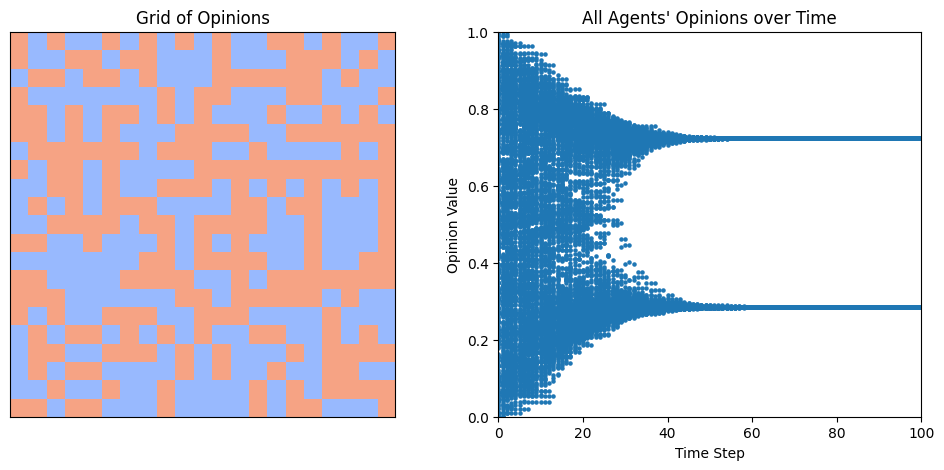

In [11]:
# ======================================================
# パラメータ設定
# ======================================================
N =21  # グリッドの大きさ: N x N
confidence_threshold = 0.2  # 意見差がこの値以下なら相互学習
learning_rate = 0.3         # お互いの意見をどれだけ近づけるか
spatial_interactions = False # True: 近傍から相手を選ぶ / False: 全体からランダムに相手を選ぶ

NUM_STEPS = 100  # シミュレーションステップ
INTERVAL = 10   # アニメーション描画用のインターバル（ミリ秒）

# ======================================================
# メイン実行部
# ======================================================
# 1) グリッド初期化 (各セルに意見[0-1]をランダム配置)
opinion_grid = initialize_opinion_grid(N)

# 2) アニメーション作成
HTML_obj = animate_opinion_allpoints(opinion_grid, num_steps=NUM_STEPS, interval=INTERVAL)

# 3) 表示
HTML_obj
